# Module 2.3 — The Navier-Stokes Equations

**These are Newton's second law, applied to a fluid parcel.**
Nothing more, nothing less. Every term has a precise physical meaning that you should be able to state in plain English without looking at your notes. If you cannot, you will not know which term is causing problems when your solver diverges.

**Roadmap:**
1. Deriving N-S from Newton's second law — every term built from scratch
2. Physical meaning of each term — the four forces
3. The material derivative — why the convective term looks like it does
4. Non-dimensionalisation — reducing all flows to one parameter (Re)
5. Flow regimes: what Re tells you about the physics
6. Exact analytical solutions — validating your understanding
7. Why pressure is the troublemaker in incompressible flow

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Deriving Navier-Stokes from Newton's Second Law

### Step 1: Newton's second law for a fluid element

Consider a tiny parcel of fluid with mass $dm = \rho\,dV$ moving through the domain. Newton's second law:

$$dm \cdot \mathbf{a} = \sum \mathbf{F}$$

Divide both sides by $dV$ (force per unit volume):

$$\rho \mathbf{a} = \sum \mathbf{f}_{\text{volume}}$$

### Step 2: What is the acceleration $\mathbf{a}$?

The parcel moves. After time $dt$, it is at a new position. Its velocity has changed both because:
- The velocity field changes in time at the same point: $\partial\mathbf{u}/\partial t$
- The parcel moved to a different location where the velocity is different: $(\mathbf{u}\cdot\nabla)\mathbf{u}$

Combined, this is the **material derivative** (or substantial derivative):

$$\mathbf{a} = \frac{D\mathbf{u}}{Dt} = \underbrace{\frac{\partial\mathbf{u}}{\partial t}}_{\text{local: field changes in time}} + \underbrace{(\mathbf{u}\cdot\nabla)\mathbf{u}}_{\text{convective: parcel moves to new location}}$$

**The convective term $(\mathbf{u}\cdot\nabla)\mathbf{u}$ in words:** The parcel carries its momentum from the old location to the new location. In 2D:
- $x$-component: $u\partial u/\partial x + v\partial u/\partial y$ — how much $u$ changes as the parcel moves in $x$ and $y$

### Step 3: The forces

Three forces act on the fluid element:

**Pressure gradient** — fluid pushed from high to low pressure:
$$\mathbf{f}_p = -\nabla p$$
Sign: negative because pressure gradient points from high to low (force points downhill).

**Viscous stress** — friction from neighbouring layers moving at different speeds. For a Newtonian fluid (linear relationship between stress and strain rate):
$$\mathbf{f}_\nu = \mu\nabla^2\mathbf{u} = \rho\nu\nabla^2\mathbf{u}$$
This smooths velocity gradients — high-speed fluid layers drag the slow layers.

**Body forces** — gravity, buoyancy, electromagnetic forces:
$$\mathbf{f}_b = \rho\mathbf{g}$$

### Step 4: Assemble

$$\rho\frac{D\mathbf{u}}{Dt} = -\nabla p + \mu\nabla^2\mathbf{u} + \rho\mathbf{g}$$

Divide by $\rho$ (constant for incompressible flow, $\nu = \mu/\rho$):

$$\boxed{\frac{\partial \mathbf{u}}{\partial t} + (\mathbf{u}\cdot\nabla)\mathbf{u} = -\frac{\nabla p}{\rho} + \nu\nabla^2\mathbf{u} + \mathbf{g}}$$

Paired with the incompressibility constraint:

$$\boxed{\nabla\cdot\mathbf{u} = 0}$$

These two equations form the **incompressible Navier-Stokes system**.

## 2. Physical Meaning of Every Term

In 2D, expanding the x-momentum equation:

$$\underbrace{\frac{\partial u}{\partial t}}_{\text{(1)}} + \underbrace{u\frac{\partial u}{\partial x} + v\frac{\partial u}{\partial y}}_{\text{(2)}} = \underbrace{-\frac{1}{\rho}\frac{\partial p}{\partial x}}_{\text{(3)}} + \underbrace{\nu\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right)}_{\text{(4)}}$$

| Term | Name | Physical meaning | Dominant when |
|------|------|-----------------|---------------|
| (1) $\partial u/\partial t$ | Unsteady/local | Rate at which velocity changes at a fixed point in space | Transient flows: startup, oscillations, turbulence |
| (2) $(\mathbf{u}\cdot\nabla)u$ | **Convection** | Momentum carried by the flow — velocity field transports itself | High Re: source of turbulence, instability, nonlinearity |
| (3) $-(1/\rho)\nabla p$ | **Pressure gradient** | Force from high-pressure to low-pressure region | Always present — this is what drives the flow |
| (4) $\nu\nabla^2 u$ | **Viscous diffusion** | Friction smooths velocity gradients between layers | Low Re: dominates near walls, in slow flows |

### The convective term — why it causes all the difficulty

Term (2) is **nonlinear**: $u$ appears multiplied by its own derivative. This circularity means:

- You cannot simply solve the momentum equation for $\mathbf{u}$ — the equation depends on $\mathbf{u}$ itself.
- Superposition does not apply: two solutions cannot be simply added.
- This term is the origin of turbulence, vortex shedding, and flow separation.
- It is also the source of the CFL condition: explicit discretisation of $(u\partial_x u)$ requires $\Delta t \leq \Delta x/|u|$.

### A concrete example: what happens in a constriction

A pipe narrows at some point. By continuity ($\nabla\cdot\mathbf{u}=0$), the velocity must increase. Term (2) says: as the fast fluid moves into the constriction, it carries more momentum ahead — the velocity profile changes shape. Term (3) says: the pressure drops across the constriction (Bernoulli). The solver must balance all four terms simultaneously.

## 3. Non-Dimensionalisation and the Reynolds Number

### Why non-dimensionalise?

A simulation of water in a 1 mm microchannel and a simulation of air around a 10 m wing are completely different in scale. But if both have the same Reynolds number, they have the same dimensionless flow structure — the same vortices, the same separation point, the same wake pattern.

### The scaling

Choose a velocity scale $U$, a length scale $L$, a time scale $L/U$, and a pressure scale $\rho U^2$. Substitute $\mathbf{u} = U\tilde{\mathbf{u}}$, $x = L\tilde{x}$, $t = (L/U)\tilde{t}$, $p = \rho U^2 \tilde{p}$:

$$\frac{\partial\tilde{\mathbf{u}}}{\partial\tilde{t}} + (\tilde{\mathbf{u}}\cdot\tilde{\nabla})\tilde{\mathbf{u}} = -\tilde{\nabla}\tilde{p} + \frac{1}{Re}\tilde{\nabla}^2\tilde{\mathbf{u}}$$

where:

$$\boxed{Re = \frac{UL}{\nu} = \frac{\text{inertia (convective term)}}{ \text{viscosity (diffusion term)}}}$$

**Re is the only parameter in the incompressible N-S equations** (when $\mathbf{g}$ is neglected). Two geometrically similar flows with the same Re are dynamically similar — the dimensionless velocity fields are identical.

### Flow regimes

| Re range | Flow character | Example |
|----------|---------------|--------|
| $Re \ll 1$ | Creeping (Stokes) flow. Viscosity dominates. Reversible. | Bacteria swimming, MEMS |
| $Re \sim 1$–100 | Laminar, steady. Both terms matter. | Lab microfluidics |
| $Re \sim 100$–1000 | Laminar with structure. Recirculation zones. | Your cavity solver |
| $Re \sim 10^3$–$10^5$ | Transition to turbulence. Periodic shedding. | Pipe flow, cylinder |
| $Re > 10^5$ | Fully turbulent. Need turbulence model (Module 3). | Aircraft, turbines, weather |

=== N-S balance check: Poiseuille flow ===
  ν·d²u/dy²   = -0.020000
  (1/ρ)·dP/dx = -0.020000
  Difference  = 0.00e+00  ← should be ~0

The momentum equation dP/dx = ρν d²u/dy² is satisfied exactly → analytical solution ✓


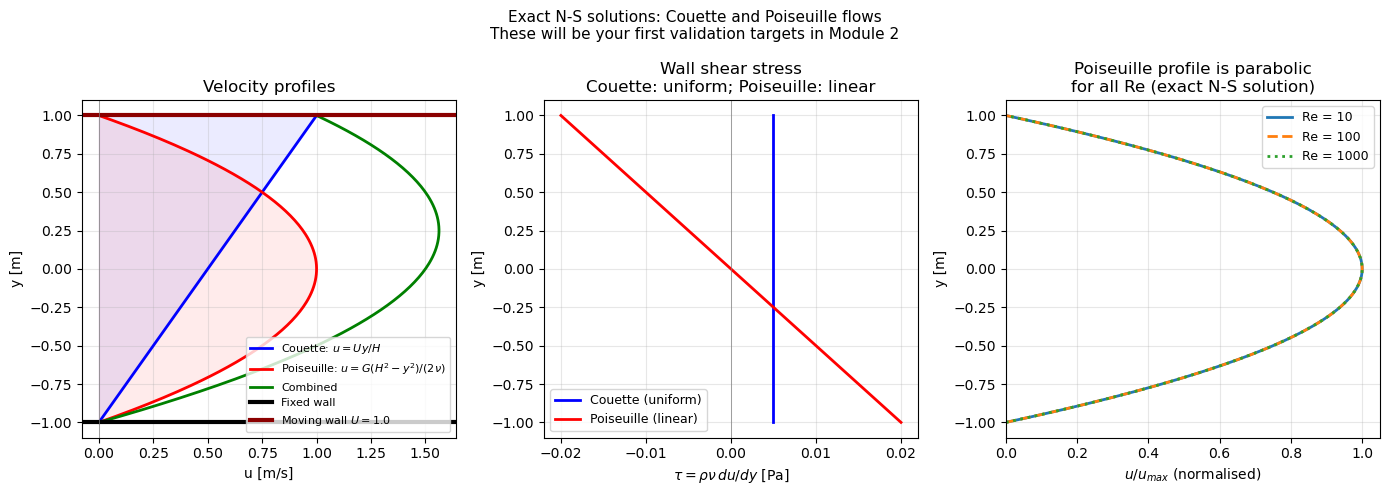

In [2]:
# ── Exact analytical solutions — validate your physical understanding ─────────
#
# Two classical exact solutions exist for simple geometry:
#
# 1. Couette flow:    two plates, upper moves at U, lower fixed
#    N-S reduces to:  d²u/dy² = 0  →  u(y) = U*y/H  (linear)
#    Physics: viscous stress is uniform across the gap
#
# 2. Poiseuille flow: two fixed plates, pressure gradient -dP/dx = G drives flow
#    N-S reduces to:  ν*d²u/dy² = (1/ρ)*dP/dx  →  u(y) = G*(H²-y²)/(2ρν)
#    Physics: viscous stress balances pressure force everywhere

# ── Parameters ───────────────────────────────────────────────────────────────
H     = 1.0    # channel half-height [m]
U_top = 1.0    # top-plate speed [m/s]
nu    = 0.01   # kinematic viscosity [m²/s]
rho   = 1.0    # density [kg/m³]
G     = 2*nu * U_top / H**2   # pressure gradient that gives same centreline speed as Couette

y     = np.linspace(-H, H, 200)

# ── Analytical profiles ───────────────────────────────────────────────────────
u_couette = U_top * (y + H) / (2*H)             # linear (upper plate moves at U_top)
u_pois    = G * (H**2 - y**2) / (2*nu)          # parabolic
u_both    = u_couette + u_pois                   # combined Couette-Poiseuille

# ── Shear stress: τ = ρν * du/dy ──────────────────────────────────────────────
tau_couette = rho * nu * U_top / (2*H)           # constant shear
tau_pois    = rho * nu * (-2*G*y) / (2*nu)       # = -G*ρ*y  (linear)

# ── N-S balance check for Poiseuille: ν*d²u/dy² should equal (1/ρ)dP/dx ──────
d2u_pois_dy2 = -G / nu   # constant: ν*(-G/ν) = -G = -dP/dx/ρ ✓
print('=== N-S balance check: Poiseuille flow ===')
print(f'  ν·d²u/dy²   = {nu * d2u_pois_dy2:.6f}')
print(f'  (1/ρ)·dP/dx = {-G:.6f}')
print(f'  Difference  = {abs(nu * d2u_pois_dy2 - (-G)):.2e}  ← should be ~0')
print()
print('The momentum equation dP/dx = ρν d²u/dy² is satisfied exactly → analytical solution ✓')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Velocity profiles
axes[0].plot(u_couette, y, 'b-', lw=2, label='Couette: $u = Uy/H$')
axes[0].plot(u_pois,    y, 'r-', lw=2, label='Poiseuille: $u = G(H^2-y^2)/(2\\nu)$')
axes[0].plot(u_both,    y, 'g-', lw=2, label='Combined')
axes[0].fill_betweenx(y, 0, u_couette, alpha=0.08, color='blue')
axes[0].fill_betweenx(y, 0, u_pois,    alpha=0.08, color='red')
axes[0].axhline(-H, color='k', lw=3, label='Fixed wall')
axes[0].axhline( H, color='darkred', lw=3, label=f'Moving wall $U={U_top}$')
axes[0].axvline(0, color='gray', lw=0.5)
axes[0].set_xlabel('u [m/s]'); axes[0].set_ylabel('y [m]')
axes[0].set_title('Velocity profiles')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Shear stress
axes[1].plot(np.full_like(y, tau_couette), y, 'b-', lw=2, label='Couette (uniform)')
axes[1].plot(-G*rho*y, y, 'r-', lw=2, label='Poiseuille (linear)')
axes[1].axvline(0, color='gray', lw=0.5)
axes[1].set_xlabel('$\\tau = \\rho\\nu\\,du/dy$ [Pa]'); axes[1].set_ylabel('y [m]')
axes[1].set_title('Wall shear stress\nCouette: uniform; Poiseuille: linear')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# Reynolds number effect on Poiseuille profile
Re_values = [10, 100, 1000]
for Re, style in zip(Re_values, ['-', '--', ':']):
    nu_re = U_top * H / Re   # kinematic viscosity for this Re
    G_re  = 2 * nu_re * U_top / H**2
    u_re  = G_re * (H**2 - y**2) / (2 * nu_re)
    u_re /= u_re.max()   # normalise to compare shapes
    axes[2].plot(u_re, y, style, lw=2, label=f'Re = {Re}')

axes[2].set_xlabel('$u/u_{max}$ (normalised)'); axes[2].set_ylabel('y [m]')
axes[2].set_title('Poiseuille profile is parabolic\nfor all Re (exact N-S solution)')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)
axes[2].set_xlim([0, 1.05])

plt.suptitle('Exact N-S solutions: Couette and Poiseuille flows\n'
             'These will be your first validation targets in Module 2', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Why Pressure is the Hard Part

### The pressure paradox

In the incompressible N-S equations, there is **no equation for pressure**. The continuity equation $\nabla\cdot\mathbf{u}=0$ does not contain $p$. The momentum equations contain $\nabla p$ but not $p$ itself. So where does $p$ come from?

**Answer:** pressure is determined by the requirement that the velocity field must be divergence-free. Pressure instantaneously adjusts itself — propagating at infinite speed — to enforce $\nabla\cdot\mathbf{u}=0$. In this sense, pressure in incompressible flow is a **constraint force**, not a thermodynamic variable.

### Deriving the pressure Poisson equation

Take the divergence of the momentum equation:

$$\nabla\cdot\left(\frac{\partial\mathbf{u}}{\partial t}\right) + \nabla\cdot[(\mathbf{u}\cdot\nabla)\mathbf{u}] = -\frac{1}{\rho}\nabla^2 p + \nu\nabla^2(\nabla\cdot\mathbf{u})$$

Since $\nabla\cdot\mathbf{u}=0$ must hold at all times: $\nabla\cdot(\partial\mathbf{u}/\partial t)=0$ and $\nabla\cdot\mathbf{u}=0$:

$$\boxed{\nabla^2 p = -\rho\,\nabla\cdot[(\mathbf{u}\cdot\nabla)\mathbf{u}]}$$

This is the **pressure Poisson equation (PPE)**. Given $\mathbf{u}$, solve for $p$. Then use $p$ to correct $\mathbf{u}$ so it satisfies continuity. This is exactly what SIMPLE does (Module 2.5).

**Key properties of the pressure field:**
- Only pressure **gradients** affect the flow — not absolute values
- Pressure is determined only up to an additive constant → must be pinned at one point
- The PPE is a global (elliptic) equation — every cell's pressure depends on every other cell
- Solving the PPE is typically 70–90% of the computational cost of an incompressible CFD simulation

## Summary

| Term | Plain English | Discretisation approach |
|------|--------------|------------------------|
| $\partial\mathbf{u}/\partial t$ | How fast velocity changes in time | Forward Euler (explicit) or BDF (implicit) |
| $(\mathbf{u}\cdot\nabla)\mathbf{u}$ | Momentum carried by the flow | Upwind (stable) or central+limiter |
| $-\nabla p/\rho$ | Pressure pushes fluid | Central difference — always second-order |
| $\nu\nabla^2\mathbf{u}$ | Viscosity smooths velocity | Implicit — avoids harsh $\Delta t$ limit |
| $\nabla\cdot\mathbf{u}=0$ | Volume is preserved | Enforced via pressure Poisson equation |

---
**Next:** Module 2.4 — Pressure-Velocity Coupling: why co-located grids cause checkerboard modes, and how staggered grids and the SIMPLE algorithm solve this.

## Exercise

**Predict first, then verify.**

1. For Couette flow ($u = Uy/H$, $v=0$, $p=0$): verify analytically that this satisfies both the continuity equation AND the x-momentum N-S equation. Which term in N-S is zero because of the geometry? Which term is non-zero?

2. A channel has $H=0.01$ m, fluid is water ($\nu = 10^{-6}$ m²/s). What pressure gradient $dP/dx$ is needed to drive a mean flow of $U_b = 0.1$ m/s? (Use: $U_b = G H^2 / (3\nu)$ for a channel of half-height $H$.)

3. Calculate the Reynolds number for: (a) blood in a capillary ($D=8\,\mu$m, $U=0.5$ mm/s, $\nu=3\times10^{-6}$ m²/s), (b) air around a Formula 1 car ($L=4$ m, $U=80$ m/s, $\nu=1.5\times10^{-5}$ m²/s). Which flow will be laminar and which turbulent?